# This notebook is about Principal Component Analysis. 

## **Scikit-learn** is a powerful library  used for preparing data and running Machine Learning classification model.

### 1\. Data Preparation and Pipelines

 * **`StandardScaler`:** **Data Normalizer.** Scales your data so that all features (columns) have the same importance level before analysis.
 * **`Pipeline`:** **Step Chain.** Used to link multiple processes (like scaling, then PCA, then classification) so they run in order automatically.
 * **`train_test_split`:** **Data Splitter.** Divides your dataset into two groups: one for training the model and one for testing its accuracy.

### 2\. Model Tools and Analysis

 * **`RandomForestClassifier`:**  A popular machine learning model (a type of ensemble model) used here to actually classify or predict the data.
 * **`PCA` (Principal Component Analysis):** **Data Compressor.** A technique that reduces the number of features (bands) in your dataset while keeping most of the important information.
 * **`cross_validate`:** **Model Tester.** A tool for rigorously checking how well your model performs by testing it on multiple different subsets of your data.

Importing relevant packages

In [6]:
# Importing relevant packages
# Libraries for general file handling, plotting, and data structures
import os
import matplotlib.pyplot as plt
import geopandas # Library for handling geospatial vector data
import pandas as pd
import seaborn as sn # Library for statistical data visualization (used for heatmaps)
import numpy as np
from pyspatialml import Raster # Library for working with geospatial rasters

In [7]:
# Libraries imported from scikit-learn for machine learning and data transformation
from sklearn.preprocessing import StandardScaler # For standardizing (scaling) data
from sklearn.pipeline import Pipeline # For chaining steps (scaling -> PCA -> Classification)
from sklearn.model_selection import cross_validate # For cross-validation (though not fully utilized here)
from sklearn.model_selection import train_test_split # For splitting data into training and testing sets
from sklearn.ensemble import RandomForestClassifier # The RF model used for testing PCA features
from sklearn.decomposition import PCA # The core library for Principal Component Analysis

Setting up the directory

In [8]:
os.chdir(r'/workspace/VY/') # Set the current working directory to the 'VY' training area data folder

Loading the data (landslide presence/absebce points)

In [25]:
data=pd.read_csv('sample_points.csv') # Load the sample points (features and labels) for the VY area

In [26]:
data.head() # Display the first few rows to inspect the data structure

,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,tri,tpi,roughness,slope,aspect,profile,planform,Landslide
0,3.77,0.56,1.07,1.02,1.41,3.57,0.41,17.25,0.78,1.13,1.09,1.32,0.37,1.63,1.57,1.06,1.00,0.83,1
1,3.77,4.47,2.39,1.86,1.01,3.57,1.12,1.24,0.78,1.13,1.09,2.72,0.15,1.26,3.34,0.88,0.98,1.12,1
2,0.93,2.88,1.07,1.02,1.26,0.20,0.41,17.25,0.78,1.13,1.14,1.32,0.15,0.61,1.57,0.69,0.98,1.12,1
3,3.77,0.00,2.39,1.86,1.26,3.57,0.41,0.13,0.78,1.13,1.09,0.58,0.37,1.63,1.57,1.06,1.06,1.12,1
4,3.77,2.88,1.07,1.86,1.41,3.57,3.22,0.13,0.78,1.13,1.09,0.58,0.37,1.63,0.39,1.25,0.98,1.12,1


Separating features from labels

In [27]:
X = data.iloc[:, 0:-1] # Select all columns except the last one as features (X)

In [28]:
y = data["Landslide"] # Select the "Landslide" column as the target labels (y)

Splitting the data into training (70%) and testing (30%)

In [29]:
# Split X and y into training (70%) and testing (30%) sets.
# random_state=42 ensures the split is the same every time (reproducibility).
# stratify=y ensures the same proportion of landslide/non-landslide points in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # Initial split using a 30% ratio 
# It is also possible to manually split the dataset into training data and testing:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=[type here], random_state=42, stratify=y) # Final split using a fixed number of samples for the test set, ensuring class balance (stratify=y)

Standardizing the data before PCA

In [30]:
scaler=StandardScaler().fit(X_train) # Initialize and fit the scaler to the TRAINING data (important: only fit on training data)
standardized_train_data = scaler.transform(X_train) # Transform the training data by scaling (mean=0, variance=1)

Creating a PCA model. 16 Principal Components are chosen, because they retain 95% of variance in our data. It reduces the dimensionality of our dataset from 28 to 16 dimensions

In [31]:
# Initialize PCA to retain 12 components (the number '12' seems chosen for visualization/analysis here, not strictly 95% variance).
pca_model = PCA(n_components=12) 
pc_train_data= pca_model.fit_transform(standardized_train_data) # Fit PCA to the scaled training data and transform it into the new 12-dimensional PCA space.

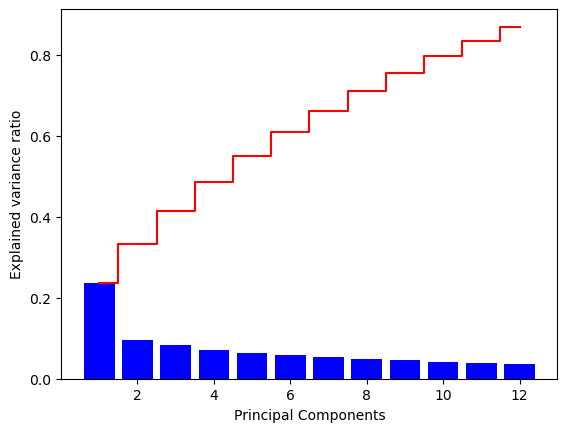

In [32]:
# Visualize the explained variance by each Principal Component (PC)

plt.bar(range(1,13), pca_model.explained_variance_ratio_, # Bar chart shows the variance explained by each individual PC.
        alpha=1,
        align='center',
       color='blue')
plt.step(range(1,13), np.cumsum(pca_model.explained_variance_ratio_), # Step plot shows the cumulative variance retained as more PCs are added.
         where='mid',
         color='red')
plt.ylabel('Explained variance ratio') # Label for the y-axis
plt.xlabel('Principal Components') # Label for the x-axis
# plt.savefig(r'C:\Users\aageen17\Desktop\figures\variance_pca.png', bbox_inches='tight', dpi=600) # Commented-out save path
plt.savefig(r'/workspace/fig/VY/variance_pca.png', bbox_inches='tight', dpi=600) # Save the plot to the workspace
plt.show() # Display the plot

In [33]:
pca_model.explained_variance_ratio_ # Display the ratio of variance explained by each of the 12 selected Principal Components.

array([0.23587143, 0.09645187, 0.08249693, 0.07200266, 0.06405117,
       0.05814451, 0.05267579, 0.04807179, 0.04510297, 0.04153267,
       0.03771412, 0.03550562])

In [34]:
pca_model.explained_variance_ratio_.cumsum() # Display the cumulative sum of the explained variance ratios.

array([0.23587143, 0.33232329, 0.41482023, 0.48682289, 0.55087406,
       0.60901857, 0.66169436, 0.70976615, 0.75486912, 0.79640178,
       0.8341159 , 0.86962153])

The first component captures around 27% of variability in our data, while the second component - around 15% and so on.
16 Principal Components explain around 97% of the variability in the data

In [35]:
# component loadings or weights (correlation coefficient between original variables and the component) 
# component loadings represent the elements of the eigenvector

loadings = pca_model.components_ # Get the component loadings (eigenvectors): these show how much each original variable contributes to each PC.
num_pc = pca_model.n_features_in_ # Get the original number of features (columns in X_train).
pc_list = ["PC"+str(i) for i in list(range(1, num_pc+1))] # Create a list of PC names (PC1, PC2, etc.).
loadings_df = pd.DataFrame.from_dict(dict(zip(pc_list, loadings))) # Create a DataFrame from the loadings, with PC names as column headers.
loadings_df['variable'] = X.columns # Add a column for the names of the original features.
loadings_df = loadings_df.set_index('variable') # Set the original feature names as the DataFrame index.
loadings_df # Display the final loadings DataFrame.

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
variable,,,,,,,,,,,,
elevation,0.379811,-0.135530,0.075931,0.176072,-0.025645,-0.059694,0.089223,-0.257347,-0.118991,-0.007373,0.055815,-0.118213
lulc,0.274940,0.061899,0.048500,-0.210056,0.081670,-0.199068,-0.086344,0.250064,-0.358394,0.447234,-0.066895,-0.065480
ndvi,0.346413,-0.057421,0.065389,-0.282227,0.204240,0.141598,0.010563,0.239195,0.078572,-0.226084,-0.123550,-0.018415
ndwi,0.291712,-0.034179,0.021080,-0.422844,0.155958,0.201125,0.073507,0.358520,0.007399,-0.185169,-0.219006,-0.029355
river,0.211752,-0.144397,0.215939,0.165129,0.409697,0.233141,-0.212036,-0.082098,0.450643,0.124173,0.234255,0.050829
road,0.320402,-0.232376,0.117539,0.067059,0.053359,-0.029999,0.174219,-0.206394,-0.020840,-0.044546,0.396643,0.127369
lithology,0.293054,-0.159863,0.073713,0.073523,-0.118381,-0.161181,0.239857,-0.360565,-0.268882,-0.039587,-0.355224,-0.305455
lithology_boundary,-0.080450,0.135563,-0.128511,0.141747,0.580181,-0.335385,0.455371,0.057289,0.246947,0.205599,-0.065216,-0.304551
fault,0.124973,-0.195629,0.218520,-0.093331,-0.538765,-0.061379,0.032246,0.188828,0.469190,0.466381,0.026995,-0.241552


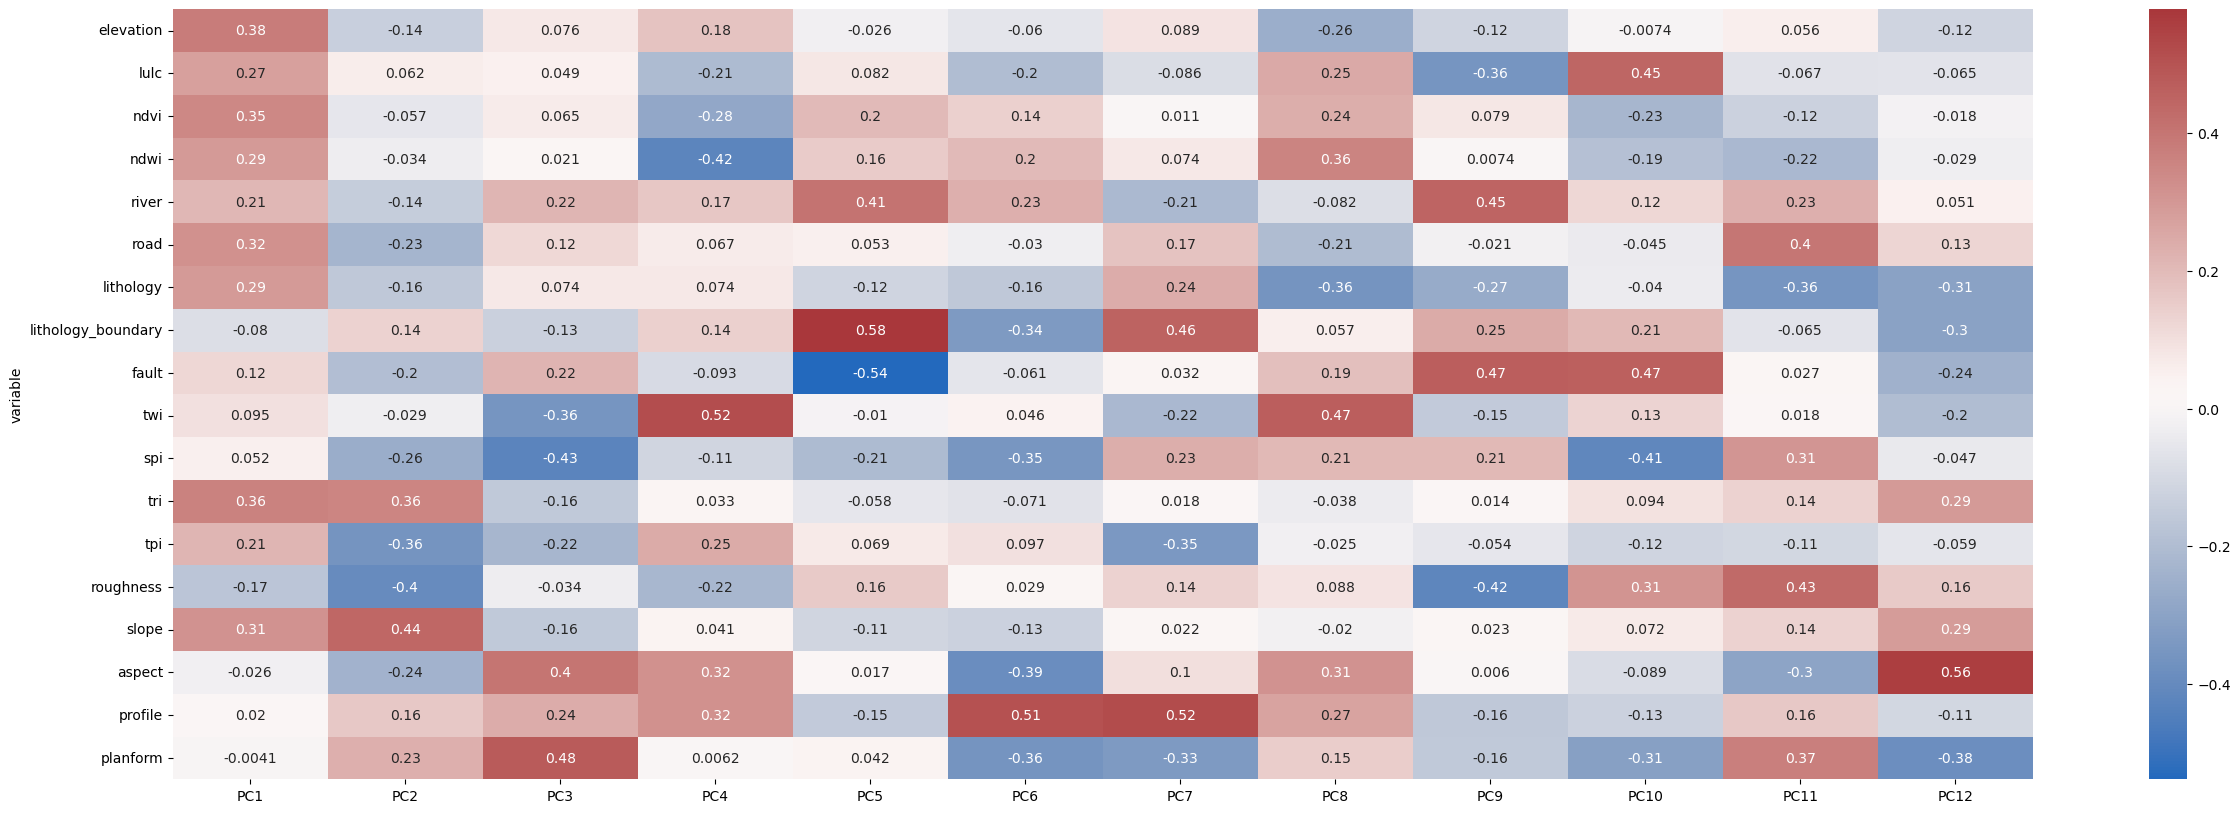

In [36]:
# get correlation matrix plot for loadings
f, ax = plt.subplots(figsize=(30, 10))
ax = sn.heatmap(loadings_df, annot=True, cmap='vlag') # Plot the loadings DataFrame as a heatmap for visual analysis.
# Annot=True displays the loading values on the map.
plt.savefig(r'/workspace/fig/VY/loadings_tal_pca.png', bbox_inches='tight', dpi=600) # Save the heatmap plot.
plt.show()

A different way of plotting it

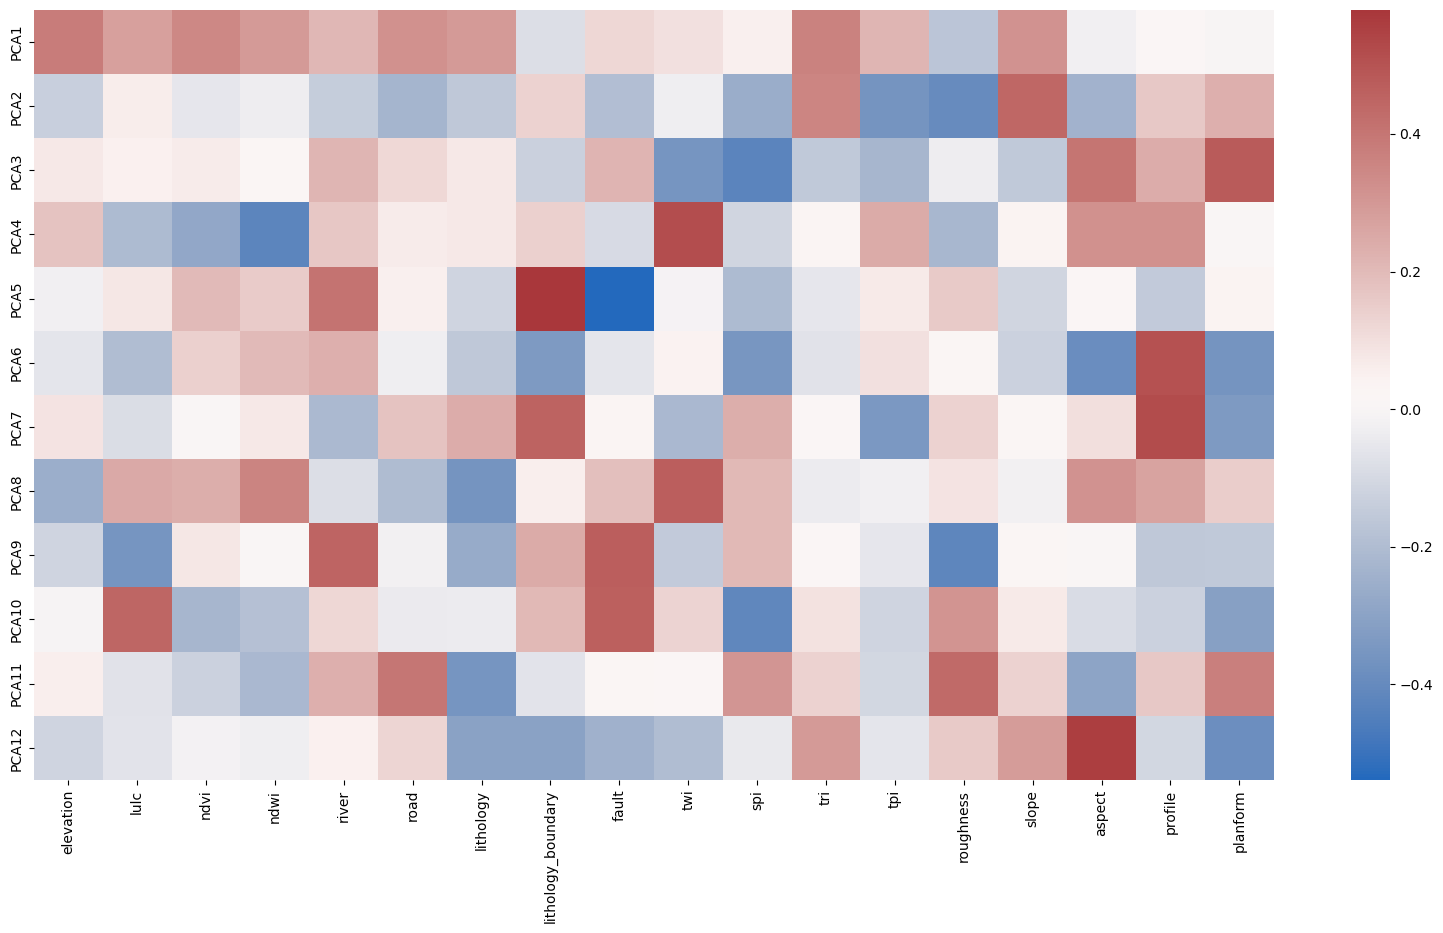

In [37]:
f, ax = plt.subplots(figsize=(20, 10))
ax = sn.heatmap(pca_model.components_, # Plot the components matrix directly.
                 cmap='vlag',
                 yticklabels=[ "PCA"+str(x) for x in range(1,pca_model.n_components_+1)], # Label rows with PC names.
                 xticklabels=list(X.columns), # Label columns with original feature names.
                 cbar_kws={"orientation": "vertical"})
# plt.savefig(r'/workspace/fig/VY/loadings_pca.png', bbox_inches='tight') 



Bioplot contains PCA loading plot which shows how much each variables effects a principal component.

PCA Loading Plot: All vectors start at origin and their projected values on components explains how much influence they have on that component. Angles between vectors indicate whether there is correlation between them - smaller angles tell about stronger correlation.

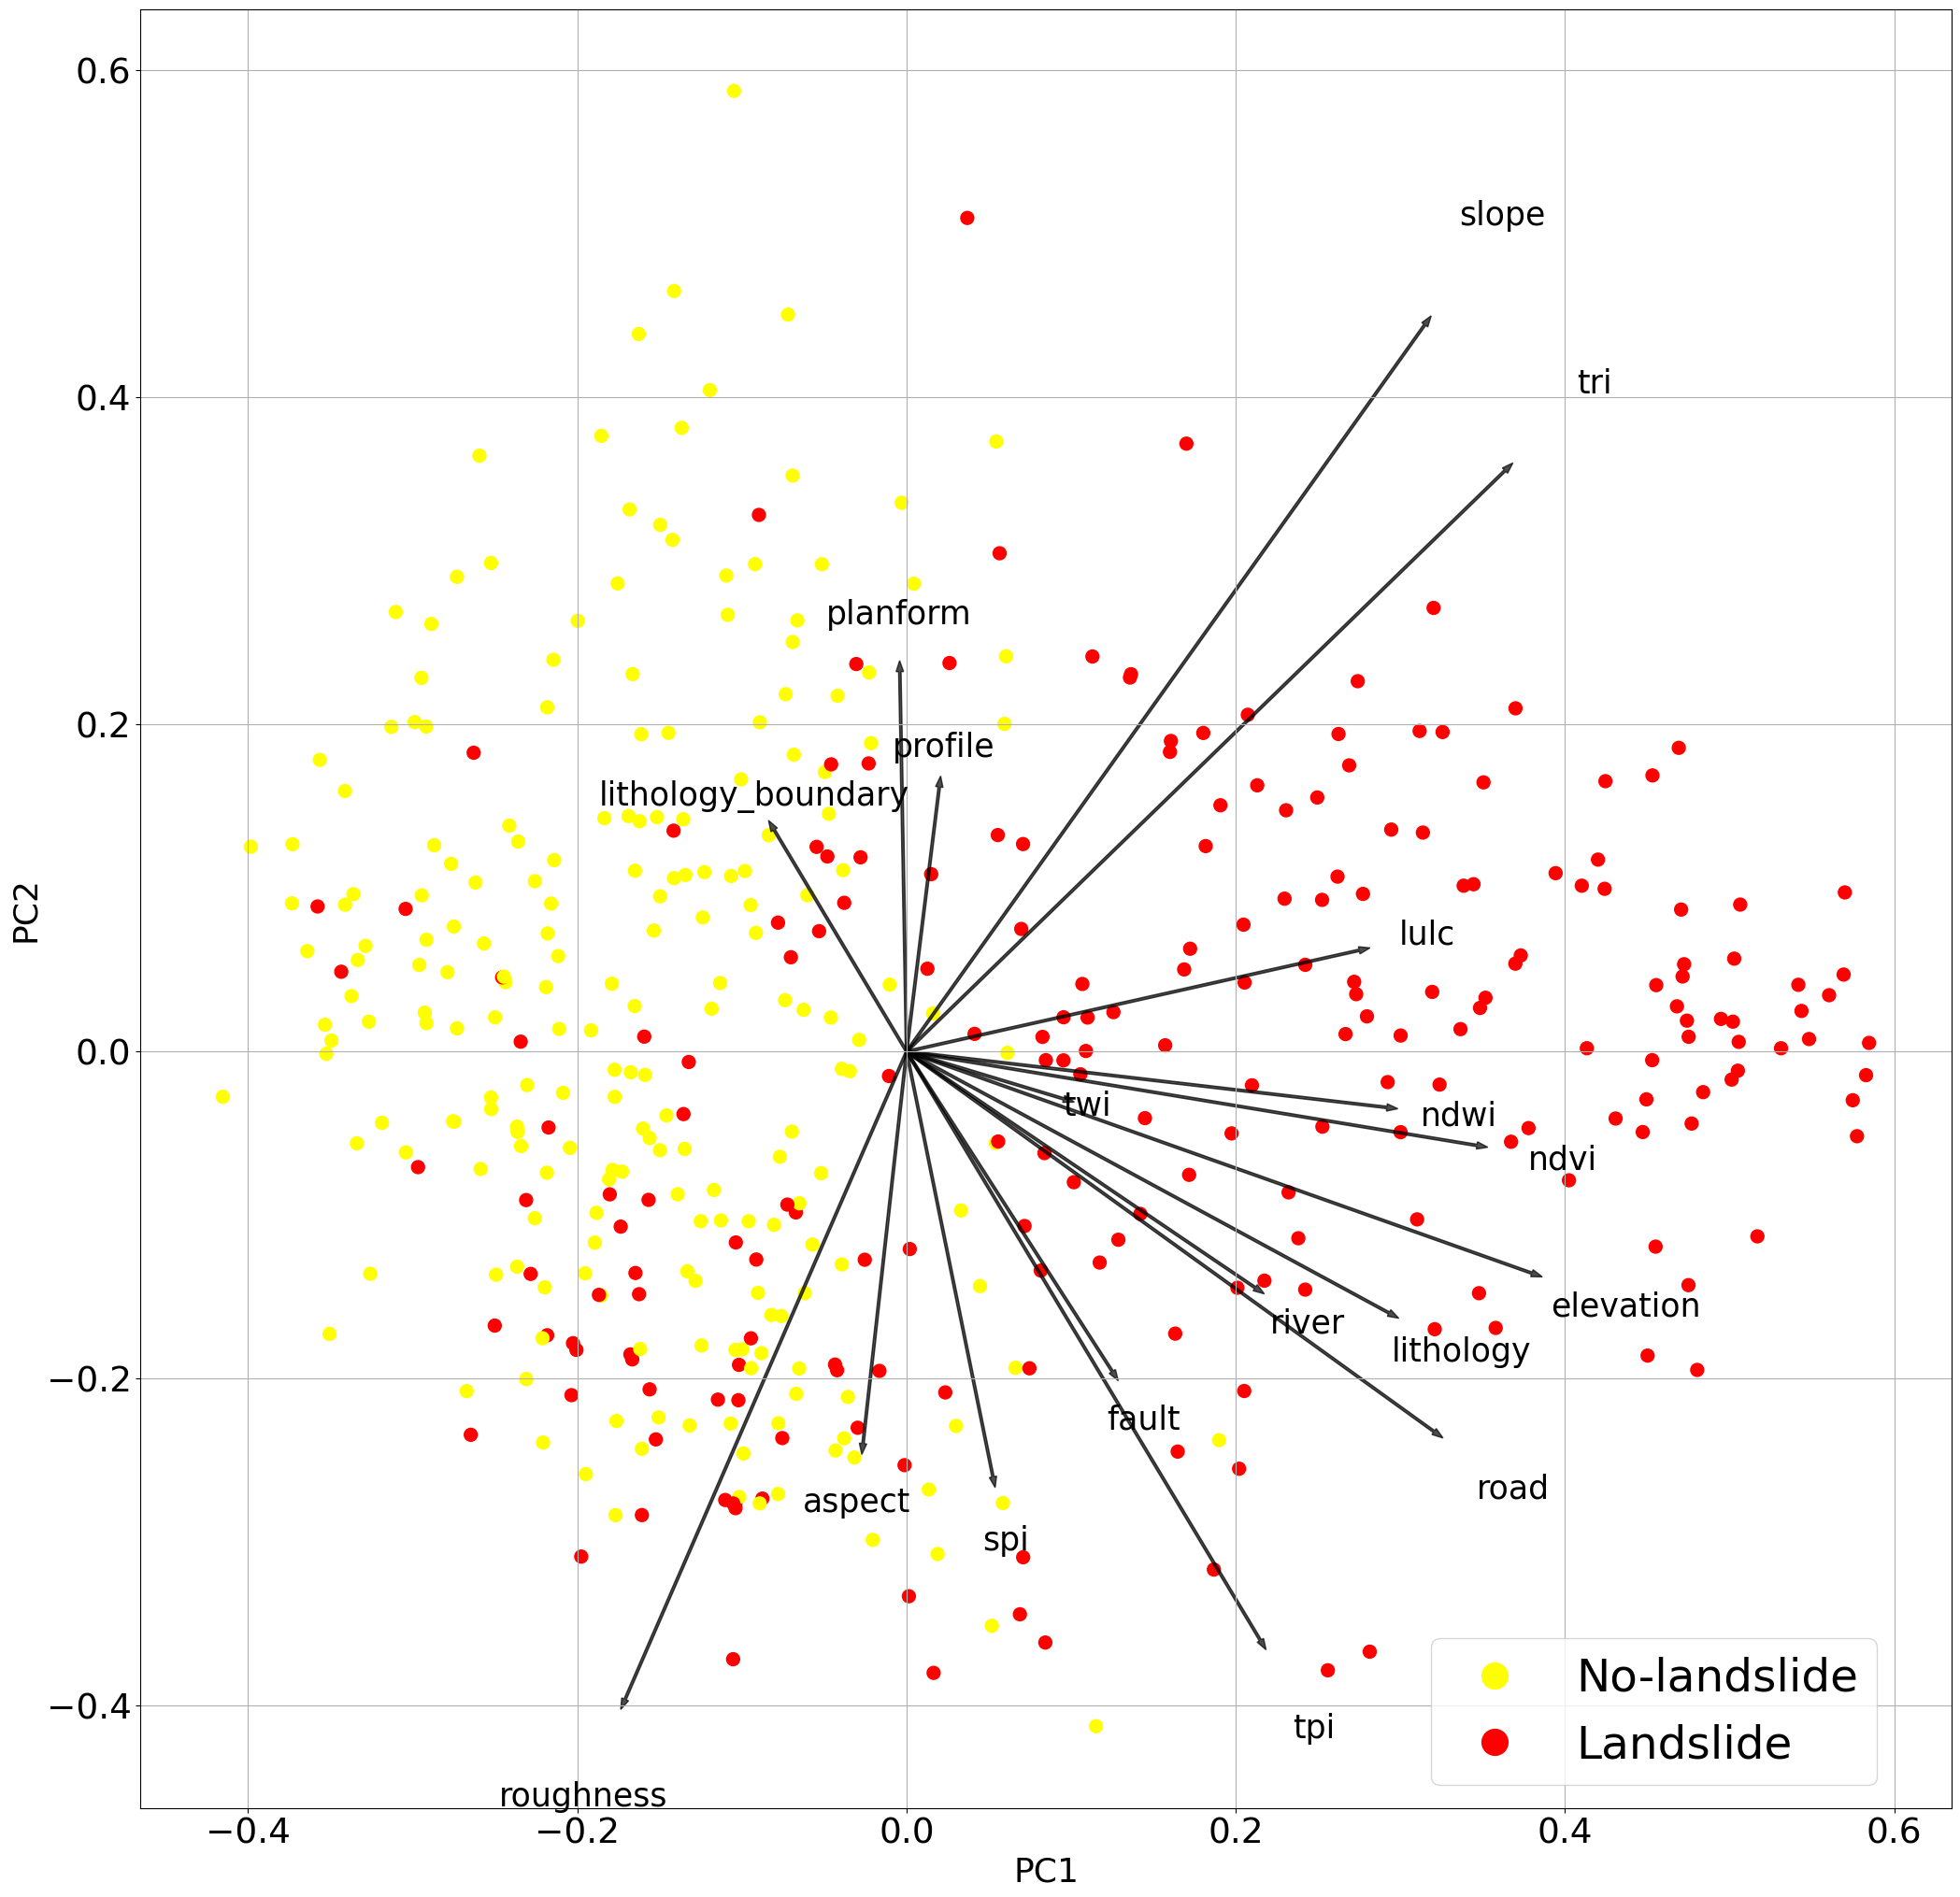

In [38]:

def myplot(score, coeff, labels=None):
    # Function to create a custom Biplot for the first two PCs (PC1 vs PC2)
    xs = score[:, 0] # PC1 scores
    ys = score[:, 1] # PC2 scores
    n = coeff.shape[0] # Number of original variables
    scalex = 1.0 / (xs.max() - xs.min()) # Scaling factor for x-axis (PC1)
    scaley = 1.0 / (ys.max() - ys.min()) # Scaling factor for y-axis (PC2)

    # Define color mapping for classes (Landslide vs. No-landslide)
    color_map = {0: 'yellow', 1: 'red'}
    colors = [color_map[label] for label in y_train]  # Assign colors based on training labels
    
    # Scatter plot of the data points in the PC space
    scatter = plt.scatter(xs * scalex, ys * scaley, c=colors, s=100, zorder=0) 
    
    # Dictionaries for custom text offsets (currently empty, using defaults below)
    label_distances = {
      
    }
    label_x_offsets = {
    
    }
    label_y_offsets = {
        
    }

    # Plot the loading vectors for original variables
    for i in range(n):
        plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], color='black', alpha=0.7, width=0.0015) # Draw vector from origin (0,0)
        if labels is None:
            plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, "Var" + str(i + 1), color='black', ha='center', va='center', fontsize=25, alpha=1.0, zorder=2)
        else:
            label = labels[i] # Original variable name
            distance = label_distances.get(label, 1.15) 
            x_offset = label_x_offsets.get(label, 0)
            y_offset = label_y_offsets.get(label, 0)
            # Place the variable label near the vector tip
            plt.text(coeff[i, 0] * distance + x_offset, coeff[i, 1] * distance + y_offset, label, color='black', ha='center', va='center', fontsize=25, alpha=1, zorder=10)

 # Create legend for class labels
    handles = [plt.Line2D([], [], marker="o", ls="", color=color_map[yi], markersize=20) for yi in color_map]
    labels = ['No-landslide' for yi in color_map]
    plt.legend(handles, ['No-landslide', 'Landslide'], loc='lower left', bbox_to_anchor=(0.70, 0.0), title_fontsize=28, fontsize=35)
    plt.xlabel("PC{}".format(1), fontsize=26) # Label x-axis as PC1
    plt.ylabel("PC{}".format(2), fontsize=26) # Label y-axis as PC2

    plt.xticks(fontsize=27) 
    plt.yticks(fontsize=27)
    
    plt.grid()

# Assuming pc_train_data, pca_model, X, and y_train are defined appropriately
f, ax = plt.subplots(figsize=(25, 25))
# Call the custom plot function with the PC scores and the loading vectors for PC1 and PC2
myplot(pc_train_data[:, 0:2], np.transpose(pca_model.components_[0:2, :]), list(X.columns)) 
plt.savefig(r'/workspace/fig/VY/loadings_plot_pca.png', bbox_inches='tight', dpi=300) # Save the biplot
plt.show()




## The resulted Principal Components can be used for Machine Learning instead of the original data. This is optional as PCA was mainly used for understanding the data.

In [ ]:
standardized_test_data=scaler.transform(X_test) # Scale the testing data using the SAME scaler fitted on the training data.

In [ ]:
pc_test_data=pca_model.transform(standardized_test_data) # Transform the scaled testing data into the PCA space using the SAME PCA model fitted on the training data.

In [ ]:
from sklearn.model_selection import GridSearchCV # For exhaustive search over parameter values
from sklearn.model_selection import RandomizedSearchCV # For randomized search over parameter values (not used here)

The resulted Principal Components can be used for Machine Learning instead of the original data. The results below are though not represented in the project, as PCA was mainly used for understanding the data. 

## Random Forest

In [ ]:
# Define hyperparameter ranges for Random Forest (for GridSearch)
# Number of trees in random forest 
n_estimators = [100, 200, 300, 500, 700, 1000, 1200]
# Number of features to consider at every split
max_features = ['auto', 'sqrt', 'log2']

In [ ]:
# Create the parameter grid
grid_rf = {'n_estimators': n_estimators,
               'max_features': max_features}
print(grid_rf)

In [ ]:
# Create a based model
rf = RandomForestClassifier()
# Instantiate the grid search model with 10-fold cross-validation (cv = 10)
grid_search_rf = GridSearchCV(estimator = rf, param_grid = grid_rf, cv = 10)

In [ ]:
grid_search_rf.fit(pc_train_data, y_train) # Train GridSearch using the PCA-transformed training data.

In [ ]:
grid_search_rf.best_params_ # Display the optimal hyperparameters found.

Creating the final RF classifier with the best hyperparameters

In [ ]:
scaler = StandardScaler() # Re-initialize scaler
pca = PCA(n_components = 11) # Re-initialize PCA, set to 11 components
# set the tolerance to a large value to make the example faster
rf = RandomForestClassifier(random_state=42, max_features= 'sqrt', n_estimators=100) # Initialize RF with the chosen best parameters (or defaults).
# Create a full pipeline: Scaling -> PCA -> RF Classification
pipeline_rf = Pipeline([('scaler', scaler), ('dims_reduction', pca), ('classifier', rf)])

In [ ]:
pipeline_rf.fit(X_train, y_train) # Train the full pipeline using the ORIGINAL (non-transformed) training data (X_train).

Creating an evaluation function

In [ ]:
from sklearn import metrics # Import metrics module
# from sklearn.metrics import plot_confusion_matrix, accuracy_score, confusion_matrix # Commented import
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Import specific confusion matrix functions
from sklearn.metrics import cohen_kappa_score # Import Cohen's Kappa score

def evaluate(model, test_features, test_labels):
    # Function to evaluate model performance on test data
    y_pred = model.predict(test_features) # Make predictions
    accuracy = metrics.accuracy_score(y_test, y_pred) # Calculate accuracy
    print (accuracy)
    print(confusion_matrix(y_test,y_pred)) # Print confusion matrix
    print(cohen_kappa_score(y_test, y_pred)) # Print Cohen's Kappa score

In [ ]:
evaluate(pipeline_rf, X_test, y_test) # Evaluate the final RF pipeline on the original test data.

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression # Import LR model

In [ ]:
lr = LogisticRegression() # Initialize LR model

In [ ]:
# Define hyperparameter ranges for Logistic Regression GridSearch
param_grid_lr = [
  {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'solver': ['liblinear'], 'penalty': ['l1','l2']}, # Solver 'liblinear' supports L1 and L2 penalty
  {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'solver': ['lbfgs'], 'penalty': ['l2']}, # Solver 'lbfgs' only supports L2 penalty
 ]

In [ ]:
# Instantiate the grid search model
grid_search_LR = GridSearchCV(estimator = lr, param_grid = param_grid_lr, 
                          cv = 10, n_jobs = -1, verbose = 2) # Use 10-fold CV and all available processors (n_jobs=-1)

# Fit the grid search to the data
grid_search_LR.fit(pc_train_data ,y_train) # Train GridSearch using the PCA-transformed training data.

In [ ]:
grid_search_LR.best_params_ # Display the optimal hyperparameters found.

Creating the final LR classifier with the best hyperparameters

In [ ]:
scaler = StandardScaler() # Re-initialize scaler
pca = PCA(n_components = 11) # Re-initialize PCA
# set the tolerance to a large value to make the example faster
lr = LogisticRegression(random_state=42, C=0.1, penalty='l2', solver='liblinear') # Initialize LR with chosen best parameters.
# Create a full pipeline: Scaling -> PCA -> LR Classification
pipeline_lr = Pipeline([('scaler', scaler), ('dims_reduction', pca), ('classifier', lr)])

In [ ]:
pipeline_lr.fit(X_train, y_train) # Train the full pipeline using the ORIGINAL training data.

In [ ]:
evaluate(pipeline_lr,X_test,y_test) # Evaluate the final LR pipeline.

## Support Vector Machine

In [ ]:
from sklearn.svm import SVC # Import SVC model

Parameters for  grid search

In [ ]:
# Define hyperparameter ranges for SVM GridSearch
param_grid_SVM = [
  {'C': [0.001, 0.1, 1, 10], 'kernel': ['linear']}, # Test linear kernel with various C values
  {'C': [0.001, 0.1, 1, 10], 'gamma': [1, 0.1, 0.01,0.001, 0.0001], 'kernel': ['rbf', 'poly', 'sigmoid']}, # Test non-linear kernels with C and gamma values
 ]

In [ ]:
# Create a based model
svm = SVC(random_state=42)
# Instantiate the grid search model
grid_search_SVM = GridSearchCV(estimator = svm, param_grid = param_grid_SVM, 
                          cv = 10, n_jobs = -1, verbose = 2)

# Fit the grid search to the data
grid_search_SVM.fit(pc_train_data,y_train) # Train GridSearch using the PCA-transformed training data.

In [ ]:
grid_search_SVM.best_params_ # Display the optimal hyperparameters found.

Creating the final SVM classifier with the best hyperparameters

In [ ]:
scaler = StandardScaler() # Re-initialize scaler
pca = PCA(n_components = 5) # Re-initialize PCA, specifically set to 5 components for the final SVM pipeline.
svm = SVC(random_state=42, C=10, gamma=0.01, kernel='sigmoid', probability=True) # Initialize SVM with chosen best parameters.
# Create a full pipeline: Scaling -> PCA -> SVM Classification
pipeline_svm = Pipeline([('scaler', scaler), ('dims_reduction', pca), ('classifier', svm)])

In [ ]:
evaluate(pipeline_svm, X_test ,y_test) # Evaluate the final SVM pipeline.

In [ ]:
evaluate(pipeline_svm, X_test ,y_test) # Evaluate the final SVM pipeline.

End.